In [ ]:
import matplotlib.pyplot as plt
from crsa.src.infojigsaw import InfoJigsawDataset
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[(1, 2), (1, 1), (2, 2), (2, 1), (3, 2), (3, 1)]


game_id               2017-9-30-23-0-7-641_3644-80cc3462-26d4-4239-9...
round_num                                                            10
starter_player                                               playerChar
target_pos                                                          0,0
clicked_pos                                                         0,0
board_dims                                                          2,3
board_shapes               diamond,circle,circle,diamond,circle,diamond
board_colors                       yellow,blue,green,blue,yellow,yellow
board_chars                                                 B,B,B,B,A,C
board_numbers                                               3,2,2,1,2,3
original_messages        not yellow<EOM>outside columns<EOM>left column
corrected_messages                                            nonesense
find                                                                 B3
Name: 1619, dtype: object

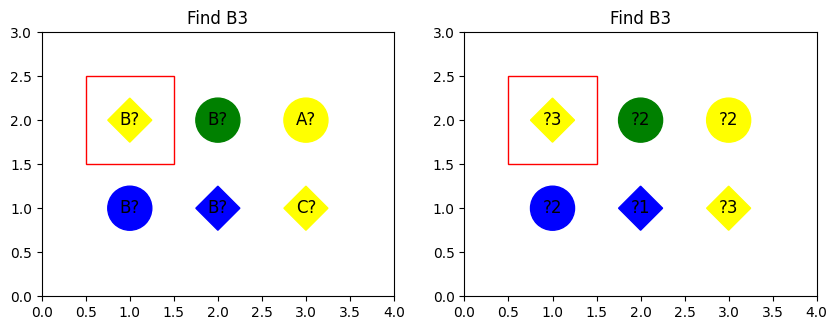

In [53]:
def convert_ij_to_xy(pos, board_dims):
    i = pos[0]
    j = pos[1]
    n_rows = board_dims[0]
    n_cols = board_dims[1]
    x = j + 1
    y = n_rows - i
    return (x, y)


def plot_board(board):
    board_dims = board['board_dims'].split(",")
    board_dims = [int(dim) for dim in board_dims]
    target_pos = board['target_pos'].split(",")
    target_pos = convert_ij_to_xy([int(pos) for pos in target_pos],board_dims)
    clicked_pos = board['clicked_pos'].split(",")
    clicked_pos = convert_ij_to_xy([int(pos) for pos in clicked_pos],board_dims)
    board_shapes = board['board_shapes'].split(",")
    board_colors = board['board_colors'].split(",")
    board_chars = board['board_chars'].split(",")
    board_numbers = board['board_numbers'].split(",")
    board_numbers = [int(num) for num in board_numbers]
    find = board['find']

    positions = [convert_ij_to_xy((i,j),board_dims) for j in range(board_dims[1]) for i in range(board_dims[0])]
    print(positions)
    fig, ax = plt.subplots(1,2, figsize=(10, 5))
    for shape, color, char, number, pos in zip(board_shapes, board_colors, board_chars, board_numbers, positions):
        if shape == 'circle':
            circle = plt.Circle(pos, 0.25, color=color)
            ax[0].add_artist(circle)
            ax[0].text(pos[0], pos[1], f"{char}?", fontsize=12, ha='center', va='center')
            circle = plt.Circle(pos, 0.25, color=color)
            ax[1].add_artist(circle)
            ax[1].text(pos[0], pos[1], f"?{number}", fontsize=12, ha='center', va='center')
        elif shape == 'square':
            square = plt.Rectangle((pos[0]-0.25, pos[1]-0.25), 0.5, 0.5, color=color)
            ax[0].add_artist(square)
            ax[0].text(pos[0], pos[1], f"{char}?", fontsize=12, ha='center', va='center')
            square = plt.Rectangle((pos[0]-0.25, pos[1]-0.25), 0.5, 0.5, color=color)
            ax[1].add_artist(square)
            ax[1].text(pos[0], pos[1], f"?{number}", fontsize=12, ha='center', va='center')
        elif shape == "diamond":
            diamond = plt.Polygon([(pos[0], pos[1]+0.25), (pos[0]+0.25, pos[1]), (pos[0], pos[1]-0.25), (pos[0]-0.25, pos[1])], color=color)
            ax[0].add_artist(diamond)
            ax[0].text(pos[0], pos[1], f"{char}?", fontsize=12, ha='center', va='center')
            diamond = plt.Polygon([(pos[0], pos[1]+0.25), (pos[0]+0.25, pos[1]), (pos[0], pos[1]-0.25), (pos[0]-0.25, pos[1])], color=color)
            ax[1].add_artist(diamond)
            ax[1].text(pos[0], pos[1], f"?{number}", fontsize=12, ha='center', va='center')
    ax[0].set_xlim(0, board_dims[1]+1)
    ax[0].set_ylim(0, board_dims[0]+1)
    ax[1].set_xlim(0, board_dims[1]+1)
    ax[1].set_ylim(0, board_dims[0]+1)
    ax[0].set_title(f"Find {find}")
    square = plt.Rectangle((target_pos[0]-0.5, target_pos[1]-0.5), 1, 1, color='red', fill=None)
    ax[0].add_artist(square)
    ax[1].set_title(f"Find {find}")
    square = plt.Rectangle((target_pos[0]-0.5, target_pos[1]-0.5), 1, 1, color='red', fill=None)
    ax[1].add_artist(square)
    ax[0].set_aspect('equal', adjustable='box')
    ax[1].set_aspect('equal', adjustable='box')


def _get_target_name(row):
    chars = row["board_chars"].split(",")
    nums = row["board_numbers"].split(",")
    target_i, target_j = row["target_pos"].split(",")
    rows, columns = row["board_dims"].split(",")
    idx = int(rows) * int(target_j) + int(target_i)
    target = chars[idx] + nums[idx]
    return target

# dataset = InfoJigsawDataset()
data = pd.read_csv("../data/twoEnglishWords_bold/processed.csv")
data["find"] = data.apply(_get_target_name, axis=1)
board = data.loc[data["game_id"].str.startswith("2017-9-30-23-0-7"),:].iloc[-1]
plot_board(board)
board

In [8]:
dataset.data.loc[0,:]

game_id               2017-10-1-0-12-19-216_9213-883402cb-b3cd-4724-...
round_num                                                             1
starter_player                                               playerChar
target_pos                                                          0,1
clicked_pos                                                         0,1
board_dims                                                          2,3
board_shapes                circle,square,square,square,diamond,diamond
board_colors                          yellow,blue,blue,green,blue,green
board_chars                                                 B,C,C,B,C,C
board_numbers                                               2,1,2,1,3,3
original_messages                                           blue square
corrected_messages                                          blue square
find                                                                 C2
Name: 0, dtype: object